In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')

total = abt['mrkt_home_impl'] + abt['mrkt_draw_impl'] + abt['mrkt_away_impl']
abt['mrkt_home_impl_norm'] = abt['mrkt_home_impl'] / total
abt['mrkt_draw_impl_norm'] = abt['mrkt_draw_impl'] / total
abt['mrkt_away_impl_norm'] = abt['mrkt_away_impl'] / total

def calibration_plots(data, title, bins=7, normalized=True):
    suffix = '_norm' if normalized else ''
    xlabel = 'normalized implied prob' if normalized else 'implied prob (raw)'
    outcomes = [
        (f'mrkt_home_impl{suffix}', 't_home_flg', 'Home win'),
        (f'mrkt_draw_impl{suffix}', 't_draw_flg', 'Draw'),
        (f'mrkt_away_impl{suffix}', 't_away_flg', 'Away win'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13)

    for ax, (impl_col, outcome_col, label) in zip(axes, outcomes):
        subset = data.dropna(subset=[impl_col, outcome_col])
        grouped = (
            subset
            .assign(bin=pd.qcut(subset[impl_col], q=bins, duplicates='drop'))
            .groupby('bin', observed=True)
            .agg(
                impl_mean=(impl_col, 'mean'),
                actual=(outcome_col, 'mean'),
                n=(outcome_col, 'count'),
            )
            .reset_index()
        )

        ece = (grouped['n'] / len(subset) * (grouped['impl_mean'] - grouped['actual']).abs()).sum()

        ax.plot(grouped['impl_mean'], grouped['actual'], marker='o')
        for _, row in grouped.iterrows():
            ax.annotate(f'n={int(row["n"])}', (row['impl_mean'], row['actual']),
                        textcoords='offset points', xytext=(0, 6), fontsize=7, ha='center')

        lo, hi = subset[impl_col].quantile(0.01), subset[impl_col].quantile(0.99)
        ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('actual frequency')
        ax.set_title(f'{label}  (n={len(subset)}  ECE={ece:.4f})')

    plt.tight_layout()
    plt.show()


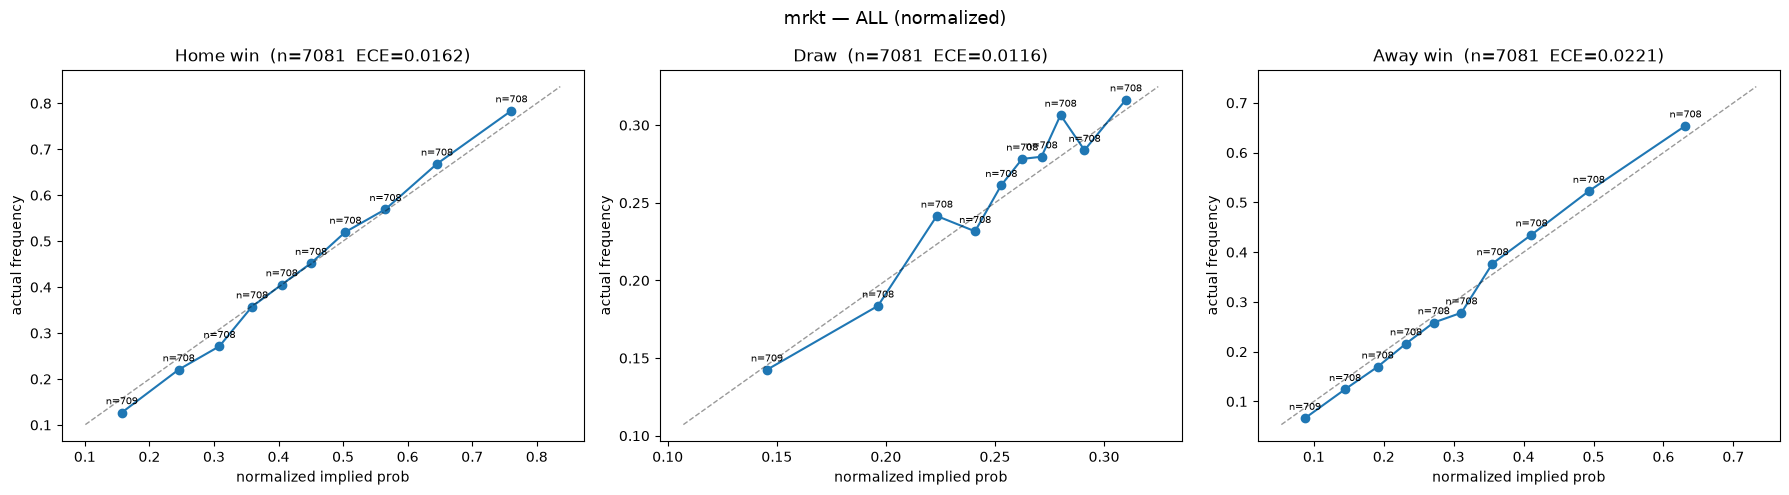

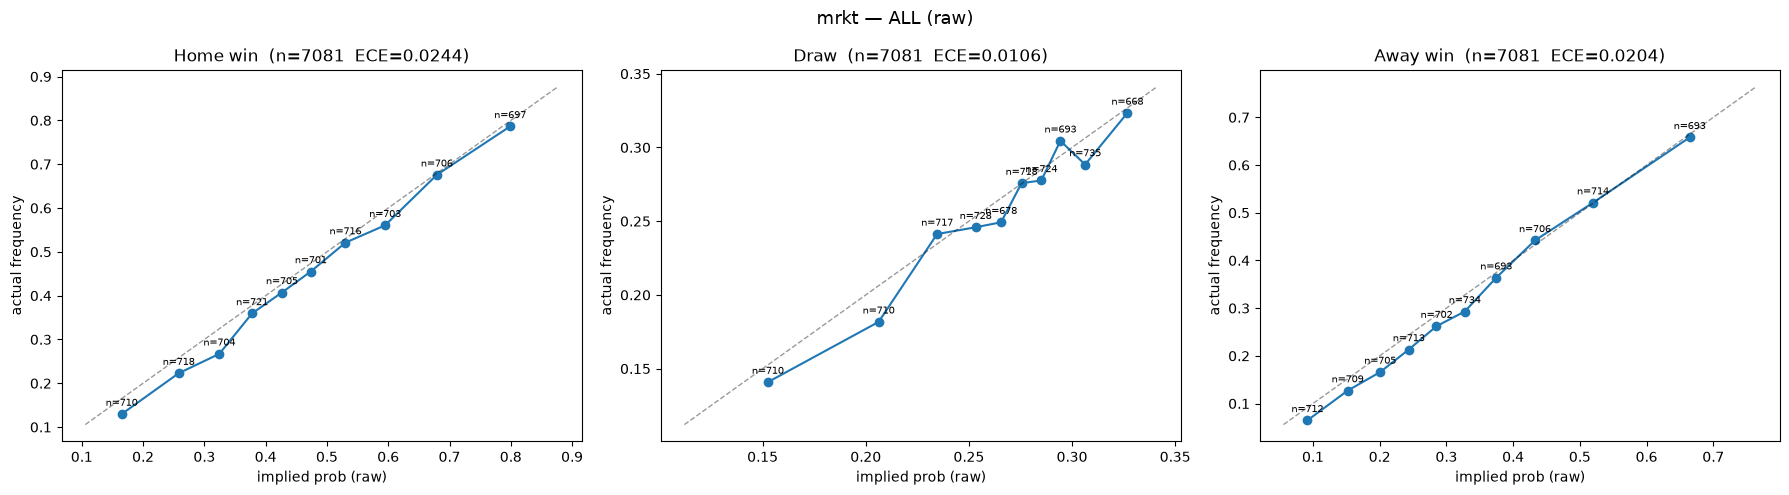

In [2]:
calibration_plots(abt, 'mrkt — ALL (normalized)', bins=10, normalized=True)
calibration_plots(abt, 'mrkt — ALL (raw)',        bins=10, normalized=False)

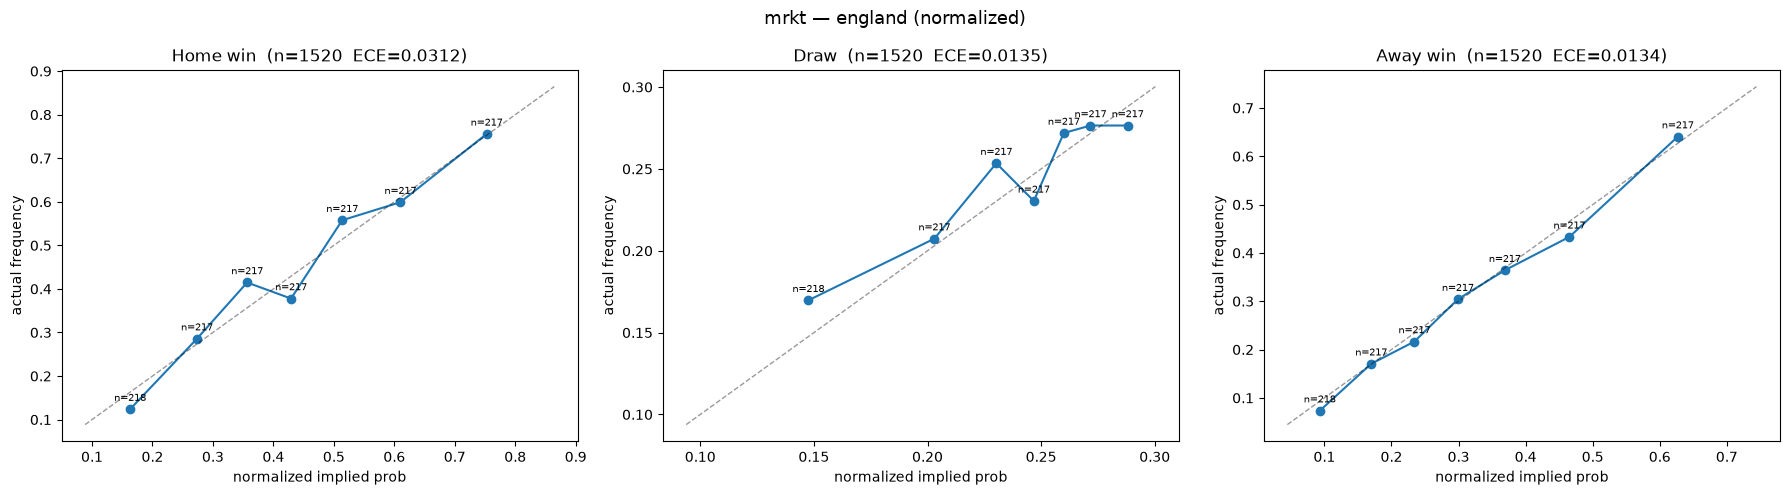

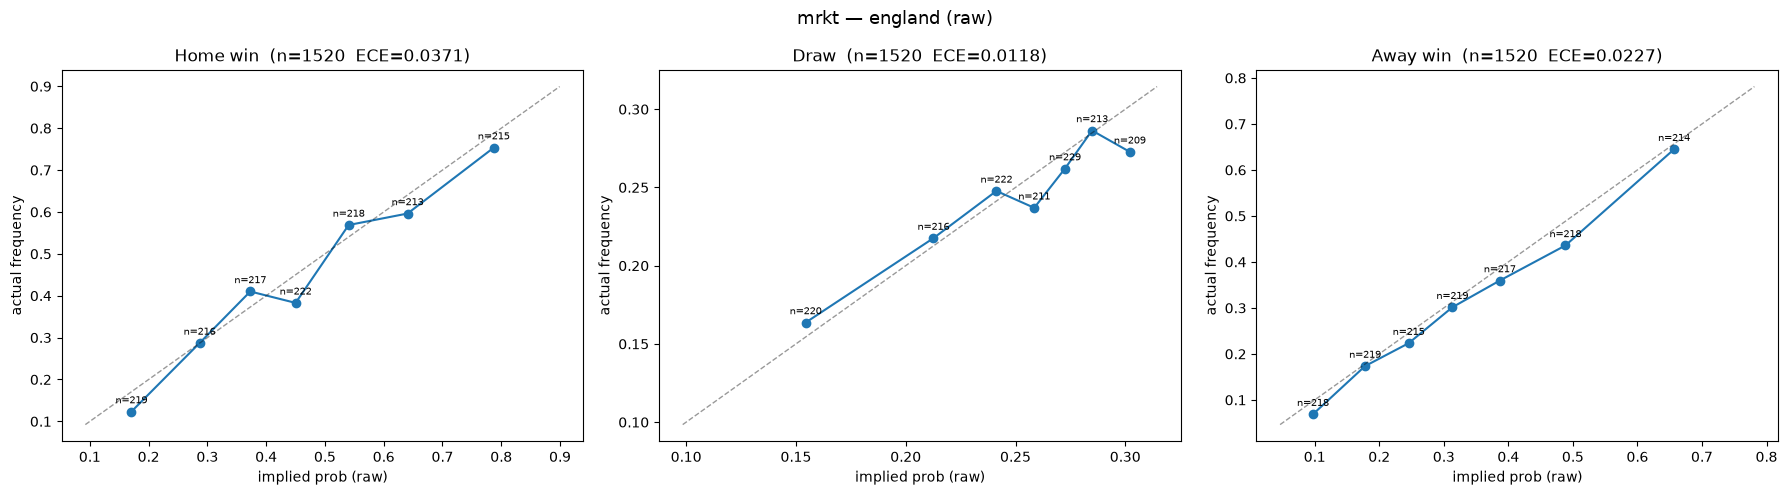

In [3]:
calibration_plots(abt[abt['league'] == 'england'], 'mrkt — england (normalized)', normalized=True)
calibration_plots(abt[abt['league'] == 'england'], 'mrkt — england (raw)',        normalized=False)

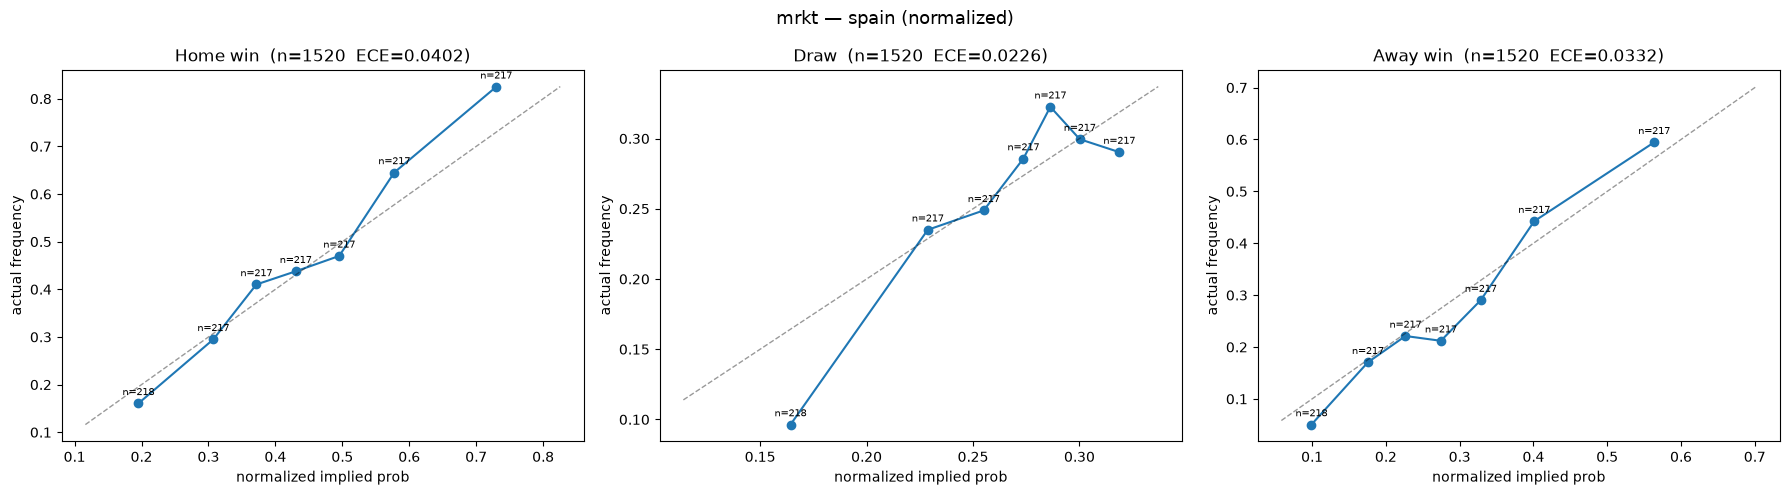

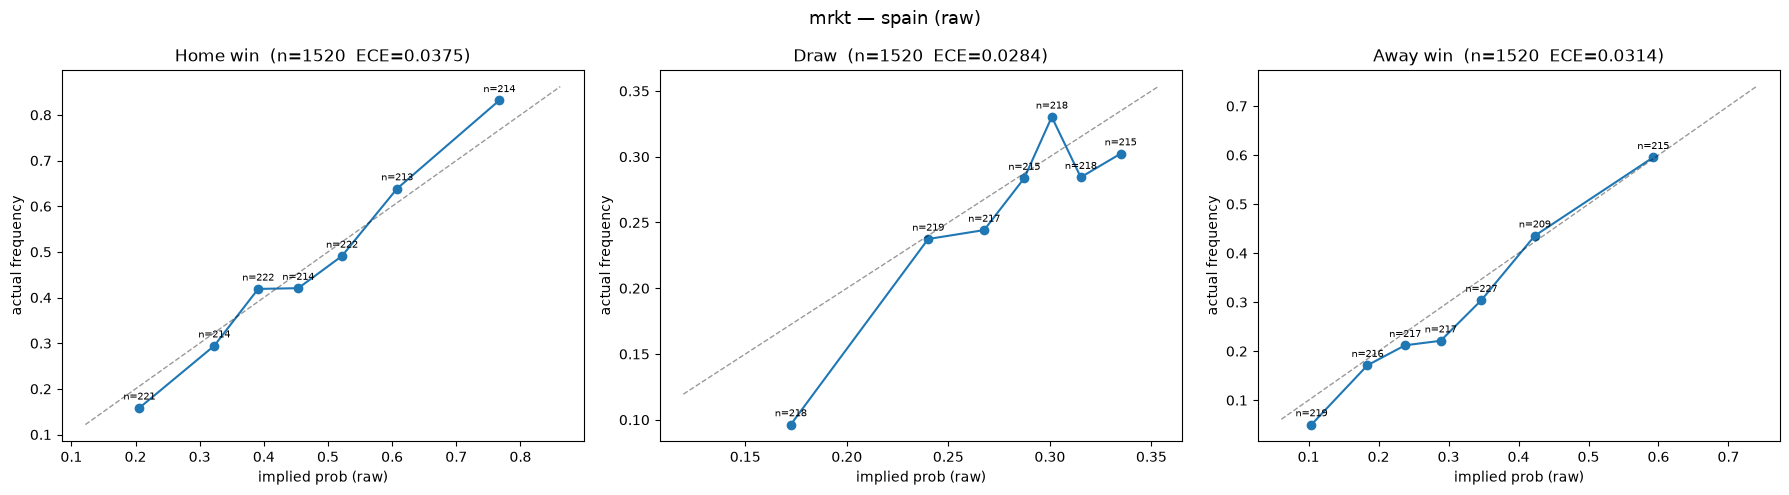

In [4]:
calibration_plots(abt[abt['league'] == 'spain'], 'mrkt — spain (normalized)', normalized=True)
calibration_plots(abt[abt['league'] == 'spain'], 'mrkt — spain (raw)',        normalized=False)

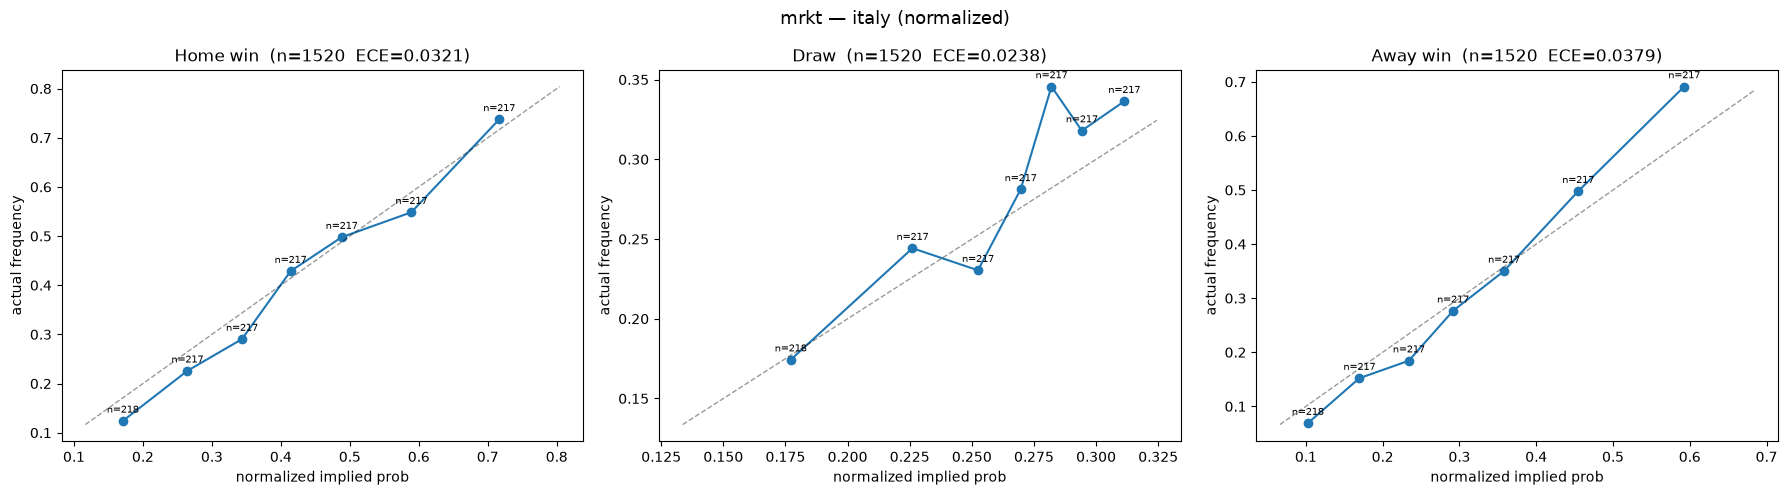

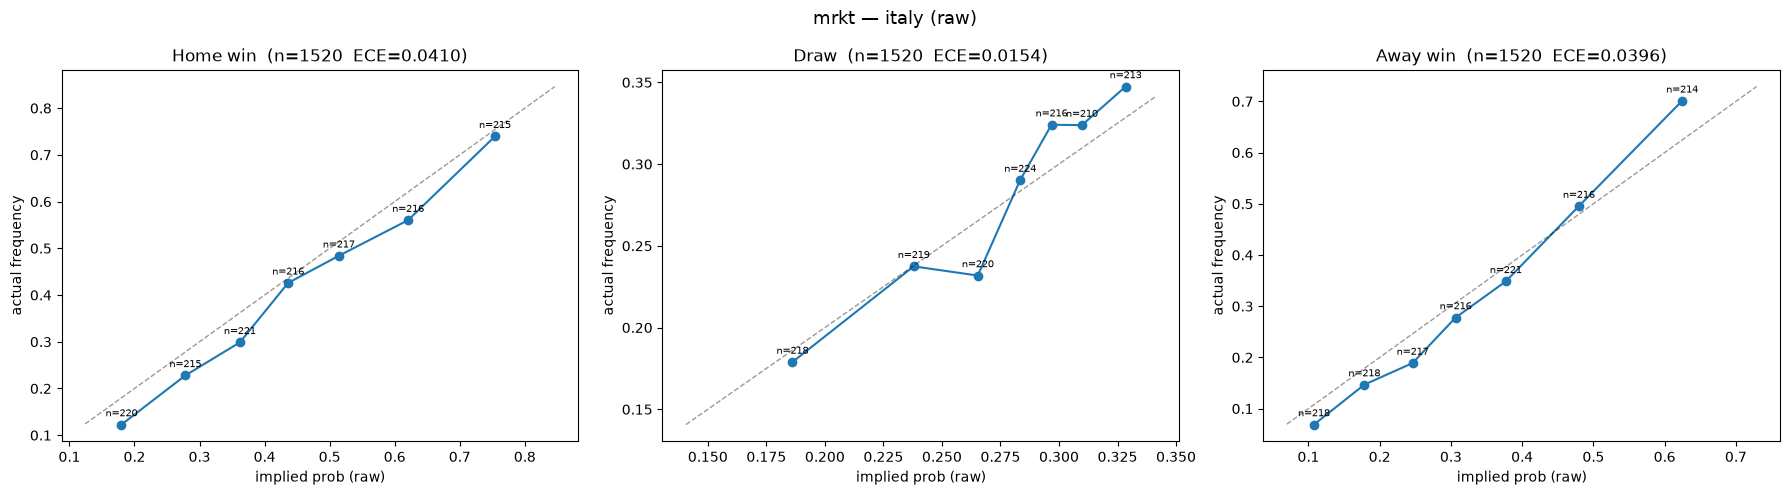

In [5]:
calibration_plots(abt[abt['league'] == 'italy'], 'mrkt — italy (normalized)', normalized=True)
calibration_plots(abt[abt['league'] == 'italy'], 'mrkt — italy (raw)',        normalized=False)

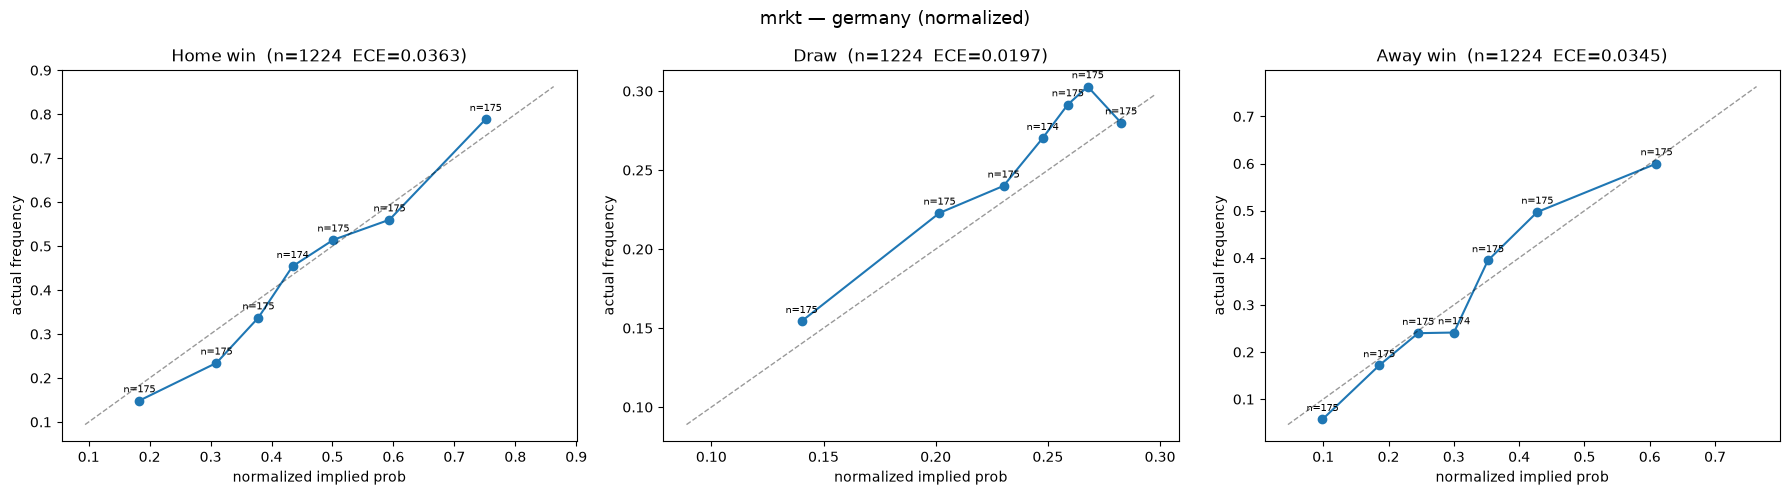

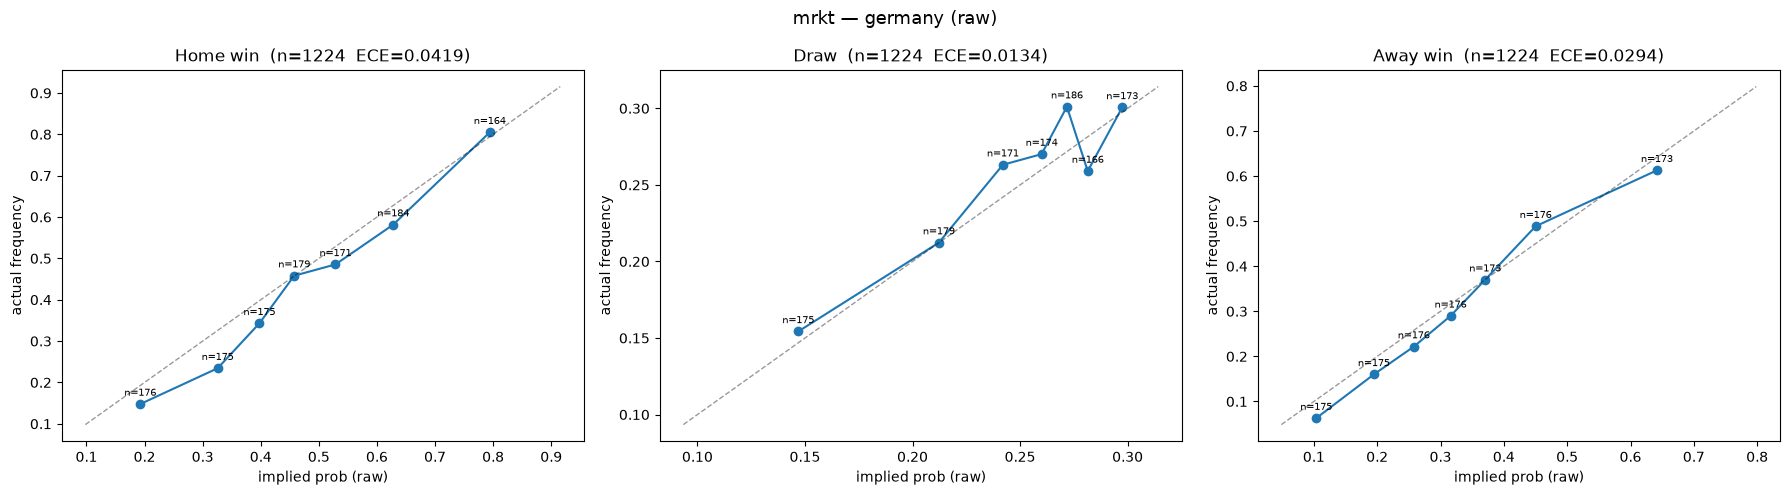

In [6]:
calibration_plots(abt[abt['league'] == 'germany'], 'mrkt — germany (normalized)', normalized=True)
calibration_plots(abt[abt['league'] == 'germany'], 'mrkt — germany (raw)',        normalized=False)

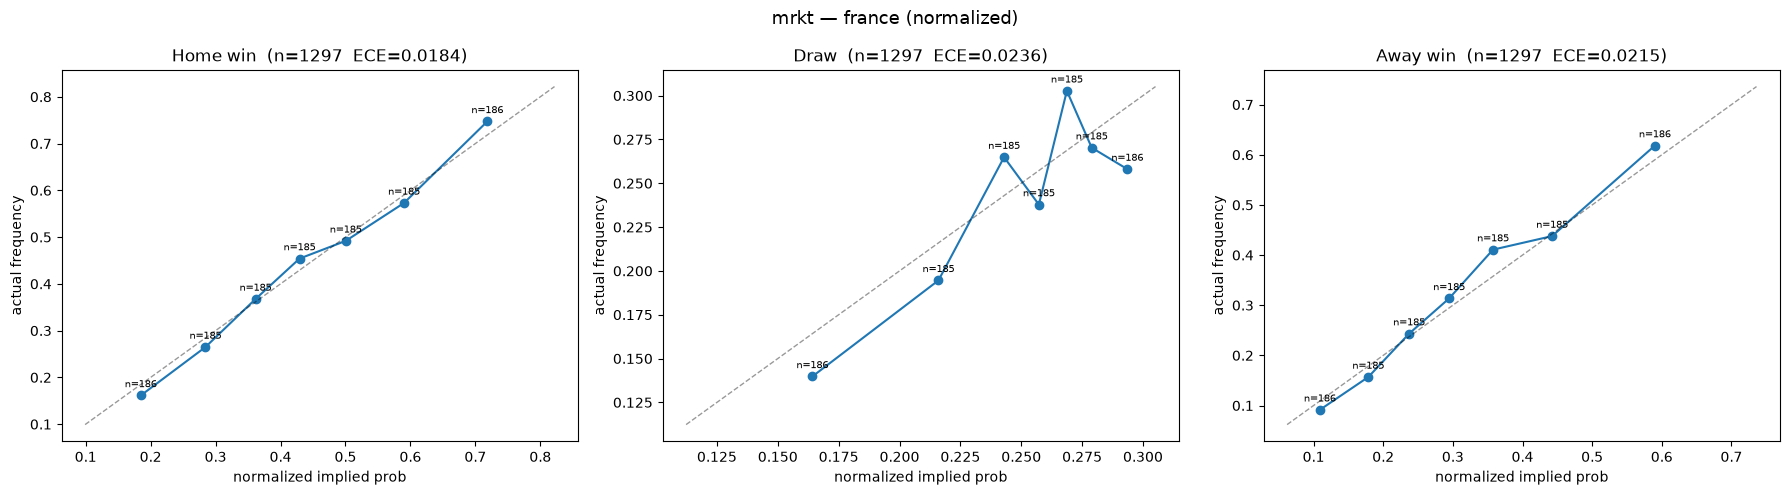

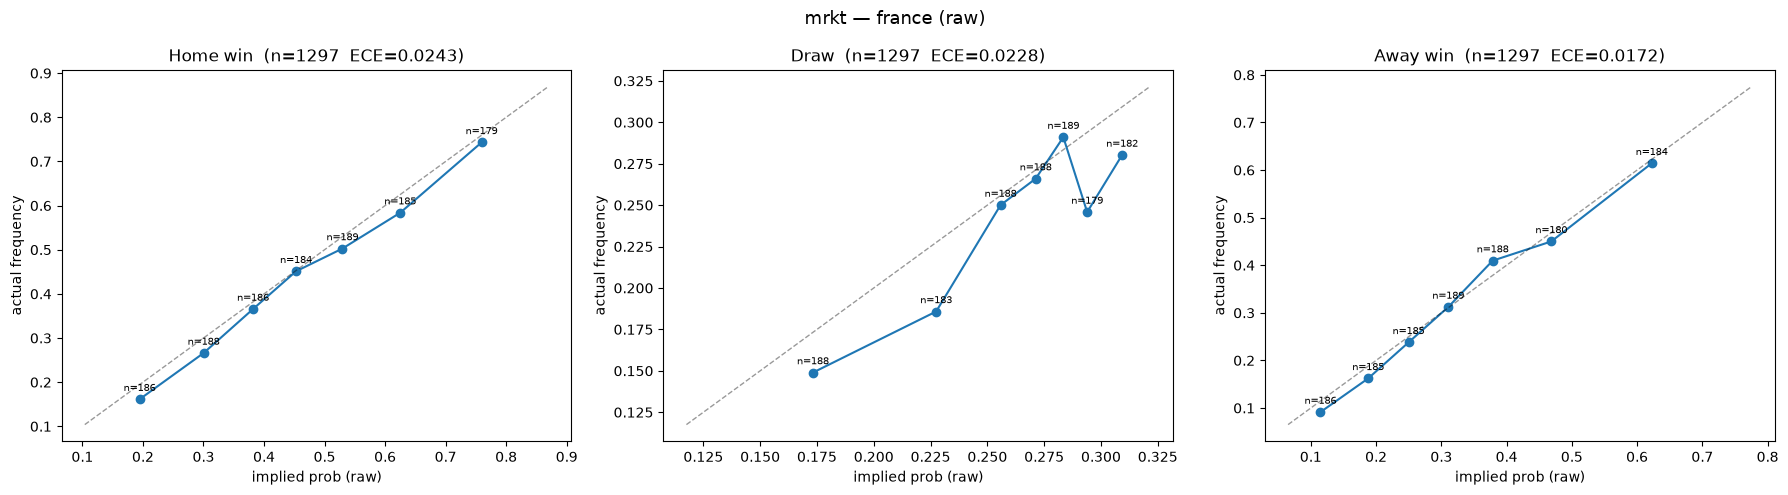

In [7]:
calibration_plots(abt[abt['league'] == 'france'], 'mrkt — france (normalized)', normalized=True)
calibration_plots(abt[abt['league'] == 'france'], 'mrkt — france (raw)',        normalized=False)

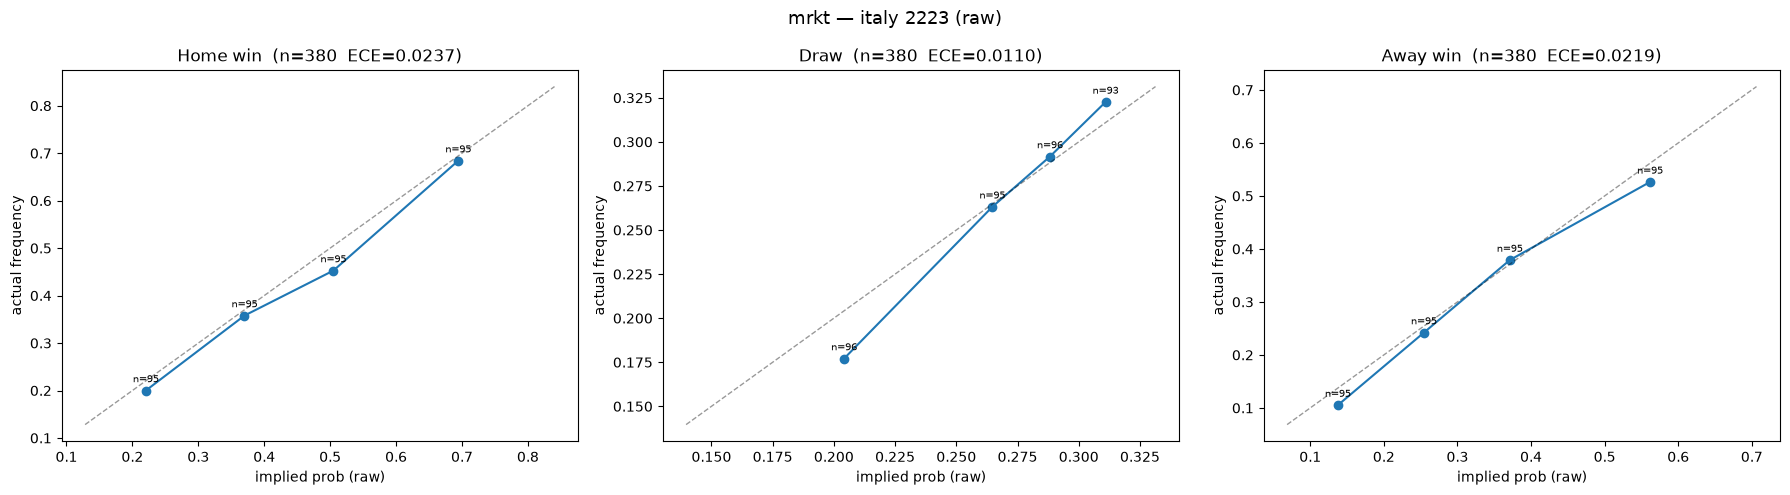

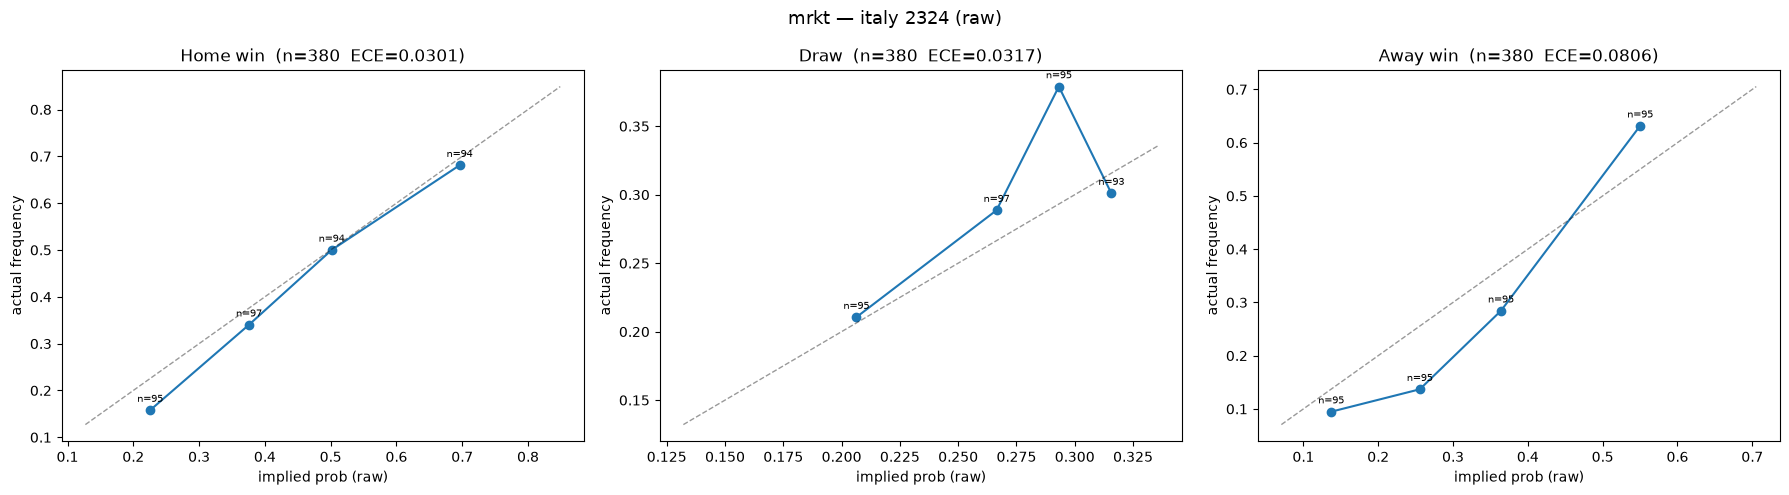

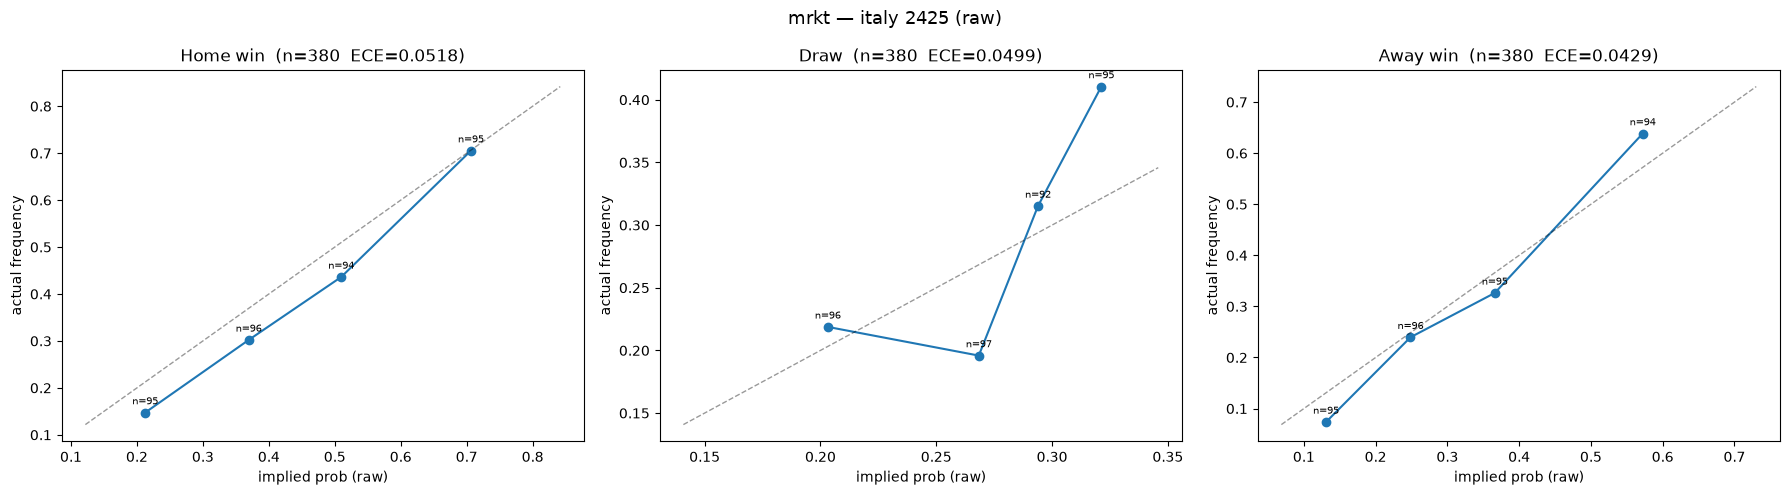

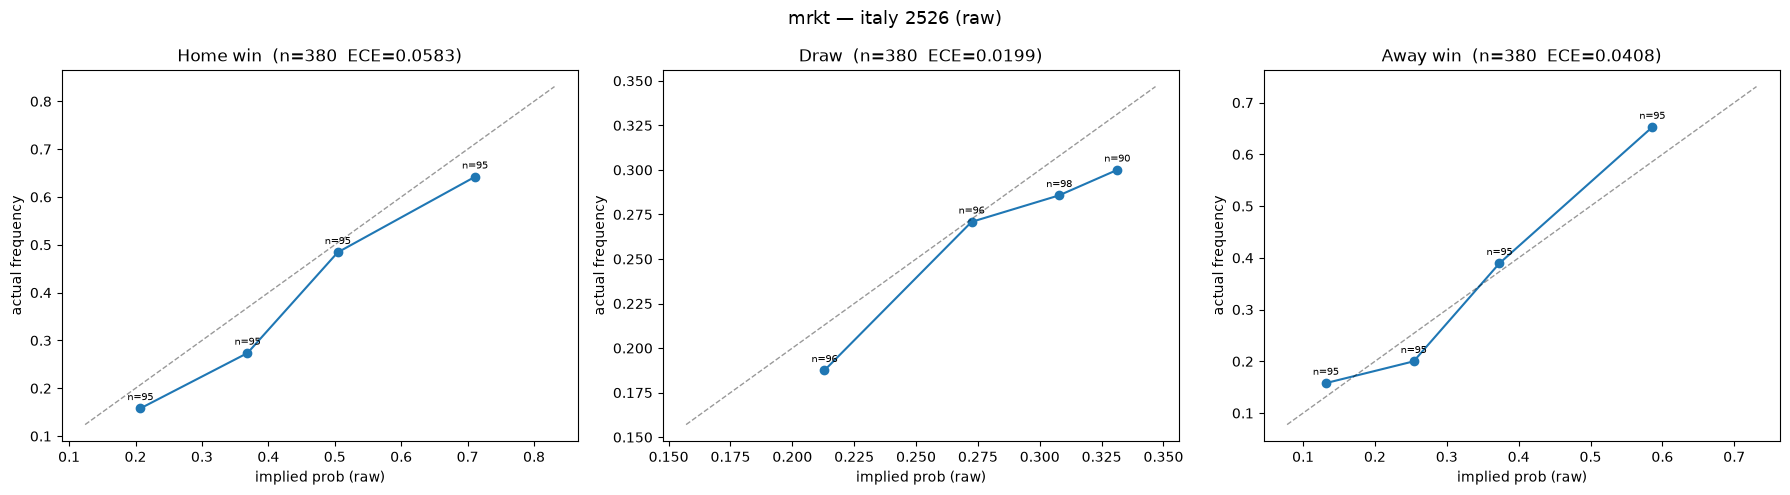

In [8]:
calibration_plots(abt.query("league == 'italy' and season == '2223'"), 'mrkt — italy 2223 (raw)', bins= 4, normalized=False)
calibration_plots(abt.query("league == 'italy' and season == '2324'"), 'mrkt — italy 2324 (raw)', bins= 4, normalized=False)
calibration_plots(abt.query("league == 'italy' and season == '2425'"), 'mrkt — italy 2425 (raw)', bins= 4, normalized=False)
calibration_plots(abt.query("league == 'italy' and season == '2526'"), 'mrkt — italy 2526 (raw)', bins= 4, normalized=False)

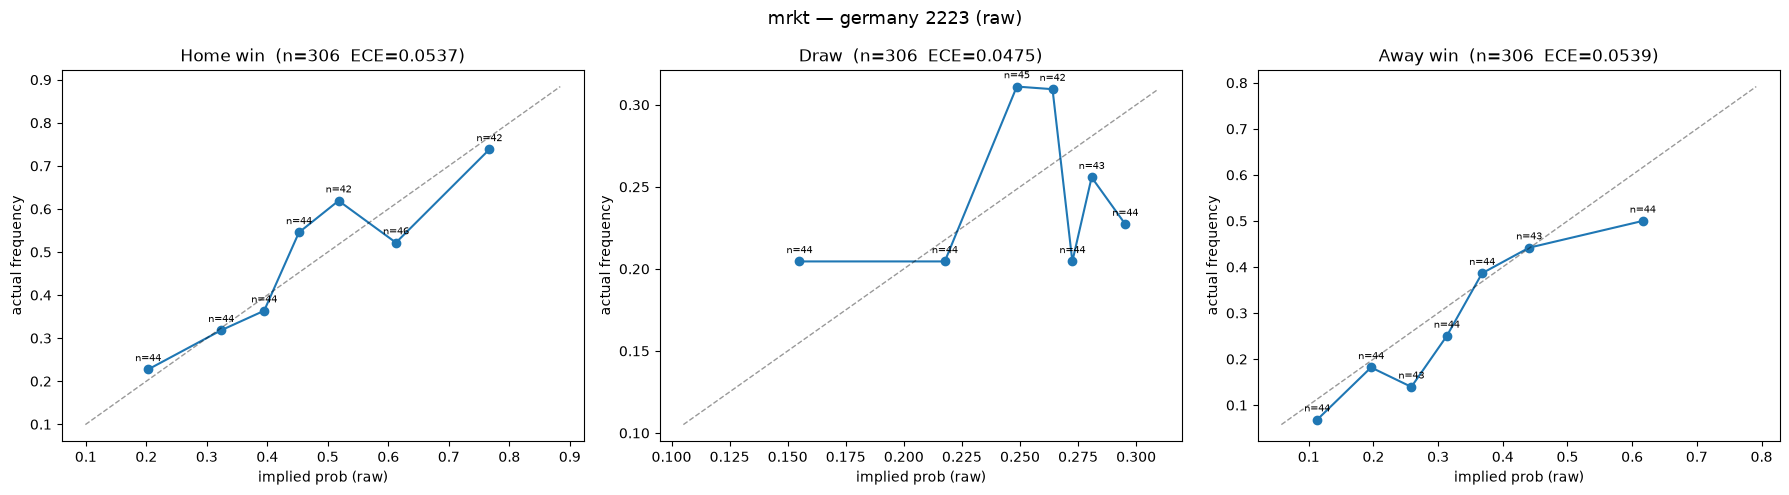

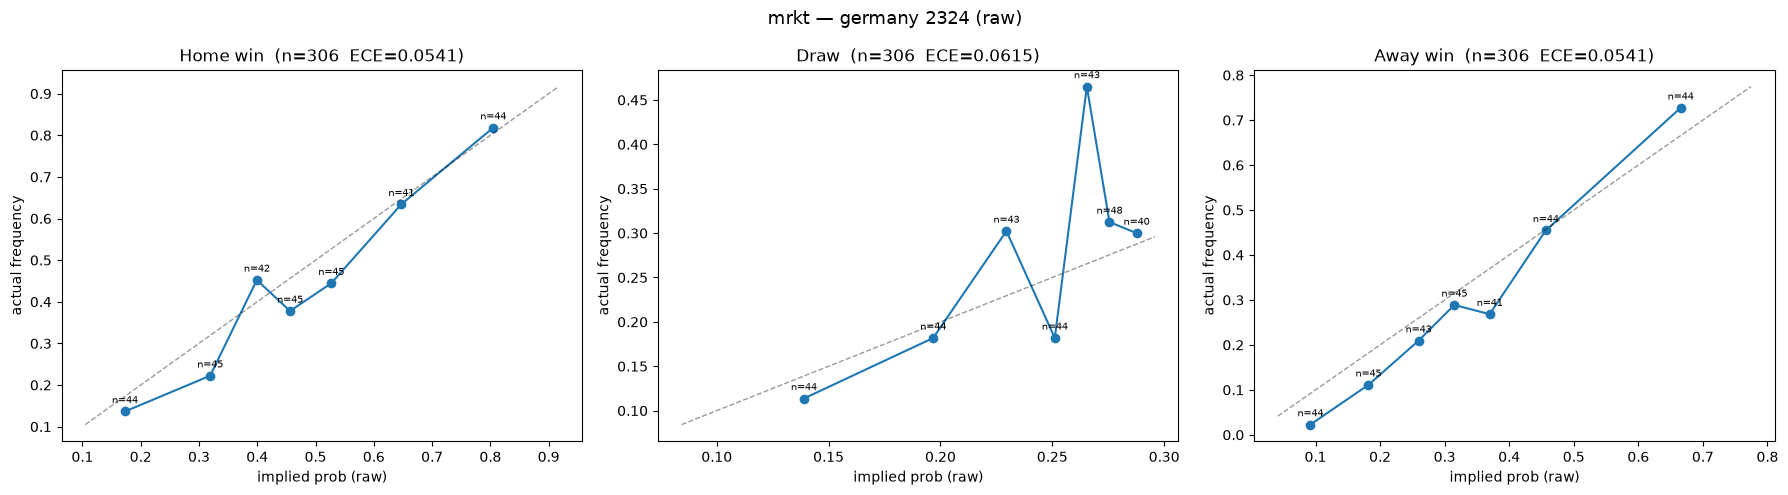

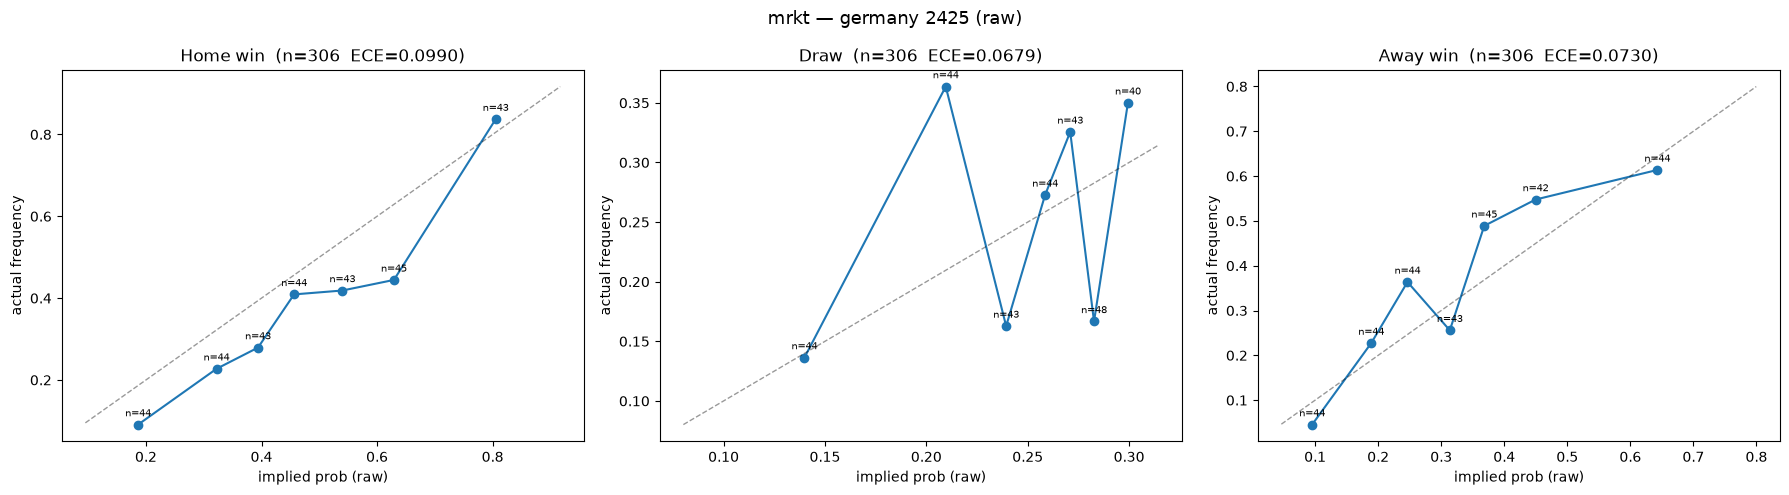

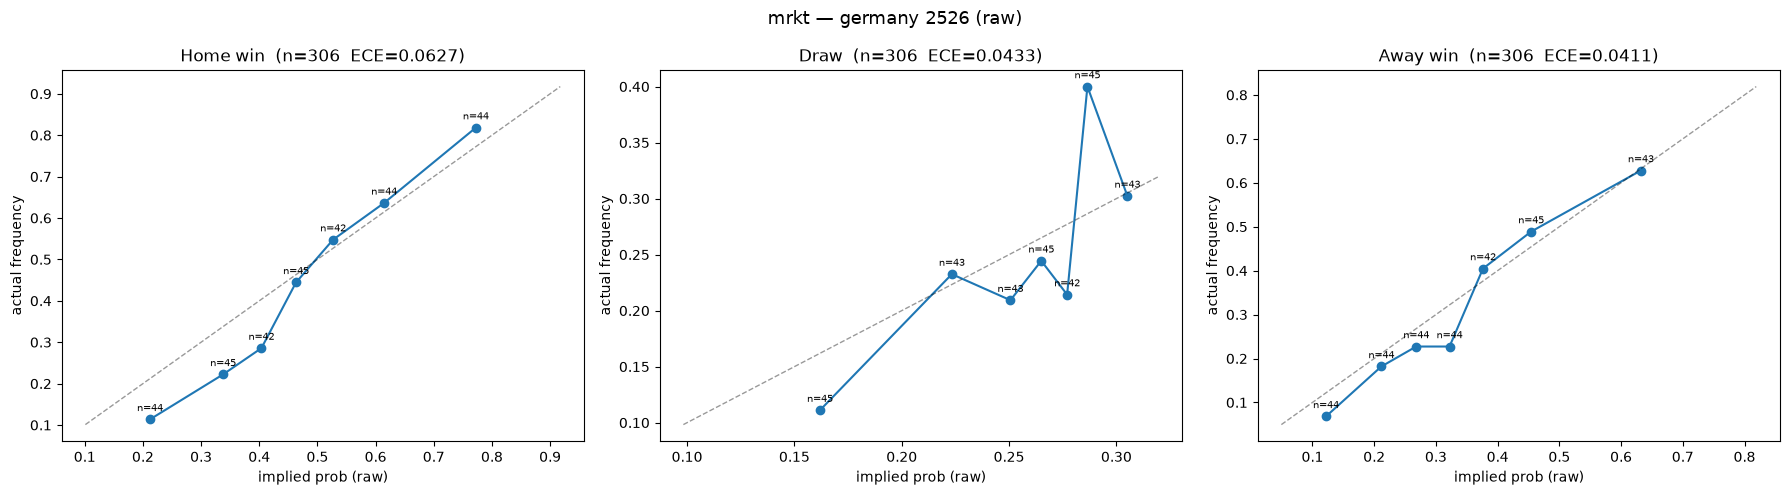

In [10]:
calibration_plots(abt.query("league == 'germany' and season == '2223'"), 'mrkt — germany 2223 (raw)', normalized=False)
calibration_plots(abt.query("league == 'germany' and season == '2324'"), 'mrkt — germany 2324 (raw)', normalized=False)
calibration_plots(abt.query("league == 'germany' and season == '2425'"), 'mrkt — germany 2425 (raw)', normalized=False)
calibration_plots(abt.query("league == 'germany' and season == '2526'"), 'mrkt — germany 2526 (raw)', normalized=False)

In [ ]:
# no repeatable results for league miscalibration. 